<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hp\AppData\Local\Temp\ipykernel_19004\3433243866.py:6: SyntaxWarning: invalid escape sequence '\P'
  dataset = pd.read_csv('D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv', header=0, index_col=0)
C:\Users\hp\AppData\Local\Temp\ipykernel_19004\3433243866.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['dec'] = np.where(final['diff'] > X, 1, 0)
C:\Users\hp\AppData\Local\Temp\ipykernel_19004\3433243866.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

              Close  MA1  MA2  diff
Date                               
12/1/2003  1.718597  NaN  NaN   NaN
12/2/2003  1.730313  NaN  NaN   NaN
12/3/2003  1.728101  NaN  NaN   NaN
12/4/2003  1.720697  NaN  NaN   NaN
12/5/2003  1.733102  NaN  NaN   NaN
              Close       MA1       MA2      diff
Date                                             
9/19/2006  1.887291  1.888062  1.798437  0.089625
9/20/2006  1.902189  1.888551  1.798861  0.089690
9/21/2006  1.901683  1.888804  1.799346  0.089458
9/24/2006  1.900599  1.888957  1.799814  0.089144
9/25/2006  1.895016  1.889304  1.800306  0.088999
Total number of buy and Sell Signal 
 dec
-1    1447
 1     452
Name: count, dtype: int64


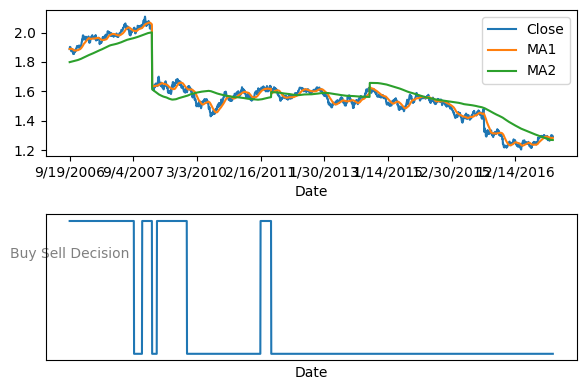

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#read input
dataset = pd.read_csv('D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv', header=0, index_col=0)
#print(dataset.head(),"\n",dataset.describe())

#taking moving averages of 28 days and 260 days sliding window method
real = dataset.Close
mv1 = dataset.Close.rolling(28).mean()
mv2 = dataset.Close.rolling(260).mean()

# convert series to frame
mv1 = mv1.to_frame()
mv2 = mv2.to_frame()
diff = mv1 - mv2

# adding new header in the column
mv1.columns = ['MA1']
mv2.columns = ['MA2']
diff.columns= ['diff']

# Adding all the columns together
frames = [real, mv1, mv2, diff]
total = pd.concat(frames, axis=1)

# check whether it contains any Nan value
print(total.head())

#drop row if there is any value zero within a row
final = total.dropna(axis=0, how="any")

# check whether it contains any Nan value after applying dropna
print(final.head())

# see the results in charts
#final[['Close','MA1','MA2']].plot(figsize=(20,10))
#plt.show()

# below is the logic when to start selling and when to buy
X = 0.05
final['dec'] = np.where(final['diff'] > X, 1, 0)
final['dec'] = np.where(final['diff'] < X, -1, final['dec'])
print("Total number of buy and Sell Signal \n",final['dec'].value_counts())

# charting the decision 
#final['dec'].plot(figsize=(20, 10))
#plt.show()

# put all together in one chart to compare the accuracy of our strategy
plt.figure(figsize=(6, 4))
plt.subplot(2, 1, 1)
final[['Close','MA1','MA2']].plot(ax=plt.gca())
plt.subplot(2, 1, 2)
final['dec'].plot()
plt.xticks(())
plt.yticks(())
plt.text(0.1, 0.5, 'Buy Sell Decision', ha='center', va='center',size=10, alpha=.5)
plt.tight_layout()
plt.show()

# ignore the following code just for referencing purpose for future use

#Create an "empty" column as placeholder for our /position signals
##final['decision'] = None
##
##for row in range(len(final)):
##   if (final['diff'].iloc[row] > X) and (final['Close'].iloc[row] > final['MA2'].iloc[row]):
##        final['decision'].iloc[row] = 1
##   if (final['diff'].iloc[row] < X) and (final['Close'].iloc[row] < final['MA2'].iloc[row]):
##        final['decision'].iloc[row] = -1  
##
##print(final['decision'].value_counts())

               Close  Rolling Mean  Bollinger High  Bollinger Low
Date                                                             
2003-12-01  1.718597           NaN             NaN            NaN
2003-12-02  1.730313           NaN             NaN            NaN
2003-12-03  1.728101           NaN             NaN            NaN
2003-12-04  1.720697           NaN             NaN            NaN
2003-12-05  1.733102           NaN             NaN            NaN
Bollinger strategy signal counts:
 bb_dec
 0    3236
-1      94
 1      91
Name: count, dtype: int64


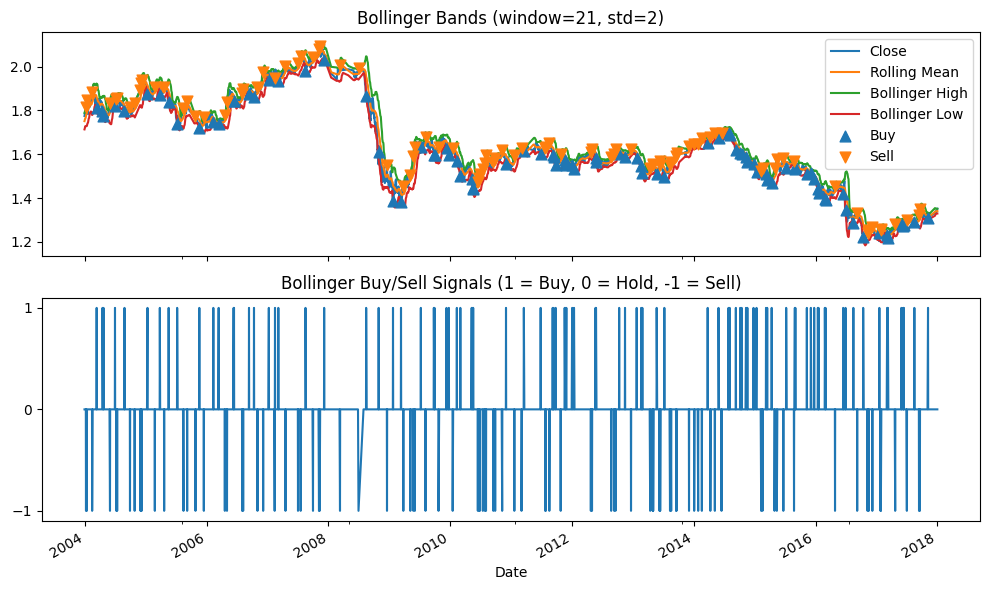

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Read input
# -----------------------------
# Use a raw string (r'...') for Windows paths to avoid backslash escapes
CSV_PATH = r'D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv'

# If your first column is Date, keep it as index; parse to datetime for nicer plots
df = pd.read_csv(CSV_PATH, header=0, index_col=0, parse_dates=True)

# Ensure 'Close' is numeric (in case the CSV has strings)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# -----------------------------
# 2) Bollinger Bands parameters
# -----------------------------
window = 21
no_of_std = 2

# -----------------------------
# 3) Compute Bollinger Bands
# -----------------------------
rolling_mean = df['Close'].rolling(window).mean()
rolling_std  = df['Close'].rolling(window).std()

df['Rolling Mean']  = rolling_mean
df['Bollinger High'] = rolling_mean + (rolling_std * no_of_std)
df['Bollinger Low']  = rolling_mean - (rolling_std * no_of_std)

# Peek
print(df[['Close','Rolling Mean','Bollinger High','Bollinger Low']].head())

# Drop rows with NaNs from the initial window
df = df.dropna(subset=['Rolling Mean','Bollinger High','Bollinger Low']).copy()

# -----------------------------
# 4) Signal logic (mean-reversion crossback)
# -----------------------------
# Buy when price re-enters from below the lower band
buy_cross = (df['Close'].shift(1) < df['Bollinger Low'].shift(1)) & (df['Close'] >= df['Bollinger Low'])
# Sell when price re-enters from above the upper band
sell_cross = (df['Close'].shift(1) > df['Bollinger High'].shift(1)) & (df['Close'] <= df['Bollinger High'])

df['bb_dec'] = 0
df.loc[buy_cross, 'bb_dec'] = 1
df.loc[sell_cross, 'bb_dec'] = -1

print("Bollinger strategy signal counts:\n", df['bb_dec'].value_counts())

# -----------------------------
# 5) Plot results
# -----------------------------
plt.figure(figsize=(10, 6))

# Top subplot: price with bands
ax1 = plt.subplot(2, 1, 1)
df[['Close','Rolling Mean','Bollinger High','Bollinger Low']].plot(ax=ax1)
ax1.set_title(f'Bollinger Bands (window={window}, std={no_of_std})')
ax1.set_xlabel('')
ax1.legend(loc='best')

# Mark buy/sell points
buy_points = df[df['bb_dec'] == 1]
sell_points = df[df['bb_dec'] == -1]
ax1.scatter(buy_points.index, buy_points['Close'], marker='^', s=60, label='Buy', zorder=3)
ax1.scatter(sell_points.index, sell_points['Close'], marker='v', s=60, label='Sell', zorder=3)
ax1.legend(loc='best')

# Bottom subplot: discrete signals
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
df['bb_dec'].plot(ax=ax2)
ax2.set_title('Bollinger Buy/Sell Signals (1 = Buy, 0 = Hold, -1 = Sell)')
ax2.set_yticks([-1, 0, 1])
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

# -----------------------------
# (Optional) Extras to experiment with:
# -----------------------------
# 1) Trend filter: only take buys if Rolling Mean rising; sells if falling
# slope = df['Rolling Mean'].diff()
# df.loc[(df['bb_dec'] == 1) & (slope <= 0), 'bb_dec'] = 0
# df.loc[(df['bb_dec'] == -1) & (slope >= 0), 'bb_dec'] = 0
# 2) Bollinger %B (0 = at low band, 1 = at high band)
# df['%B'] = (df['Close'] - df['Bollinger Low']) / (df['Bollinger High'] - df['Bollinger Low'])


In [7]:
# ===========================================
# Accuracy / Performance Evaluation for Signals
# ===========================================

import numpy as np
import pandas as pd

assert 'bb_dec' in df.columns, "bb_dec (signals) column not found."
assert 'Close' in df.columns, "Close price column not found."

# --------- (A) Hit rate on future k-day direction ----------
# For each signal, check whether the k-day forward return sign matches the signal sign.
def future_hit_rates(prices, signals, horizons=(1, 5, 10)):
    out = {}
    for k in horizons:
        fwd_ret = prices.shift(-k) / prices - 1.0
        # Only evaluate on non-zero signals
        s = signals.copy()
        mask = s != 0
        # True if sign of forward return matches sign of signal
        hits = np.sign(fwd_ret[mask]) == np.sign(s[mask])
        # Ignore NaNs from the tail (no forward price)
        hits = hits.dropna()
        out[f'{k}d_hit_rate'] = hits.mean() if len(hits) else np.nan
    return pd.Series(out)

future_hits = future_hit_rates(df['Close'], df['bb_dec'], horizons=(1, 3, 5, 10, 20))
print("\n(A) Future-return hit rates:")
print((future_hits * 100).round(2).astype(str) + "%")


# --------- (B) Trade-to-opposite evaluation ----------
# Enter on a non-zero signal; exit on the NEXT non-zero signal with opposite sign.
# If repeated same-side signals occur, we keep only the FIRST in a run to avoid double-counting.
def trade_to_opposite_stats(prices, signals):
    s = signals.copy().fillna(0).astype(int)

    # Keep only turning points (a change from prev), ignore zeros
    change_pts = s[(s != 0) & (s.shift(1) != s)].copy()
    trade_entries = change_pts.index

    trades = []
    i = 0
    while i < len(trade_entries):
        entry_idx = trade_entries[i]
        side = s.loc[entry_idx]  # +1 or -1
        # Find the next opposite-signed non-zero signal
        j = i + 1
        exit_idx = None
        while j < len(trade_entries):
            if s.loc[trade_entries[j]] == -side:
                exit_idx = trade_entries[j]
                break
            j += 1

        # If no exit signal, we can't close the trade (skip or close at last price)
        if exit_idx is None:
            # Option 1 (strict): skip the open trade
            # i += 1; continue

            # Option 2 (pragmatic): close at the final available price
            exit_idx = prices.index[-1]

        entry_px = prices.loc[entry_idx]
        exit_px = prices.loc[exit_idx]
        # Directional return
        ret = side * (exit_px / entry_px - 1.0)

        trades.append({
            'entry_time': entry_idx,
            'exit_time': exit_idx,
            'side': side,
            'entry_px': entry_px,
            'exit_px': exit_px,
            'ret': ret
        })

        i = j if exit_idx in trade_entries else j  # move on

    if not trades:
        return pd.DataFrame(), {}

    trades_df = pd.DataFrame(trades)
    win_rate = (trades_df['ret'] > 0).mean() if len(trades_df) else np.nan
    avg_ret = trades_df['ret'].mean() if len(trades_df) else np.nan
    med_ret = trades_df['ret'].median() if len(trades_df) else np.nan
    std_ret = trades_df['ret'].std(ddof=1) if len(trades_df) > 1 else np.nan
    sharpe_like = (avg_ret / std_ret) * np.sqrt(252 / max(1, trades_df['exit_time'].nunique())) if std_ret and std_ret > 0 else np.nan

    by_side = trades_df.groupby('side')['ret'].agg(['count', 'mean', 'median'])
    by_side.index = by_side.index.map({1: 'Long(+1)', -1: 'Short(-1)'})

    summary = {
        'num_trades': int(len(trades_df)),
        'win_rate': win_rate,
        'avg_trade_return': avg_ret,
        'median_trade_return': med_ret,
        'ret_std': std_ret,
        'sharpe_like': sharpe_like
    }
    return trades_df, {'summary': summary, 'by_side': by_side}

trades_df, trade_stats = trade_to_opposite_stats(df['Close'], df['bb_dec'])

print("\n(B) Trade-to-opposite stats:")
if trade_stats:
    s = trade_stats['summary']
    print(f"Trades: {s['num_trades']}")
    print(f"Win rate: {(s['win_rate']*100):.2f}%")
    print(f"Avg trade return: {s['avg_trade_return']*100:.3f}%")
    print(f"Median trade return: {s['median_trade_return']*100:.3f}%")
    print(f"Return std (per trade): {s['ret_std']*100:.3f}%")
    if s['sharpe_like'] == s['sharpe_like']:  # not NaN
        print(f"Sharpe-like (rough): {s['sharpe_like']:.2f}")

    print("\nBy side (Long/Short):")
    print(trade_stats['by_side'].to_string(float_format=lambda x: f"{x:.5f}"))
else:
    print("No trades constructed from signals.")

# --------- (Optional) Simple equity curve from trade-to-opposite ----------
# We’ll assume 1 unit per trade, no costs or slippage.
if not trades_df.empty:
    # Build PnL series by marking returns at exit points (discrete compounding)
    pnl_series = pd.Series(0.0, index=df.index)
    for _, r in trades_df.iterrows():
        pnl_series.loc[r['exit_time']] += r['ret']
    # Equity (discrete compounding into wealth)
    equity = (1 + pnl_series).replace(np.nan, 0).cumprod()
    equity.name = 'Equity (Trade-to-Opposite)'
    print("\nFinal equity (no costs):", equity.iloc[-1])
    # Quick plot (optional)
    # equity.plot(figsize=(10,4), title='Equity Curve (Bollinger Signals)')
    # plt.show()


(A) Future-return hit rates:
1d_hit_rate     50.81%
3d_hit_rate     55.14%
5d_hit_rate     54.59%
10d_hit_rate    55.68%
20d_hit_rate     57.3%
dtype: object

(B) Trade-to-opposite stats:
Trades: 84
Win rate: 76.19%
Avg trade return: 0.654%
Median trade return: 1.524%
Return std (per trade): 3.911%
Sharpe-like (rough): 0.29

By side (Long/Short):
           count    mean  median
side                            
Short(-1)     42 0.00926 0.00955
Long(+1)      42 0.00382 0.01636

Final equity (no costs): 1.6191277572196094


Bollinger strategy signal counts:
 bb_dec
 0    3236
-1      94
 1      91
Name: count, dtype: int64

=== Signal Accuracy by Horizon ===
   horizon_days  total_signals  overall_hit_rate  buy_hit_rate  sell_hit_rate
0             1            185         50.810000     46.150000      55.320000
1             5            185         54.590000     53.850000      55.320000
2            10            185         55.680000     54.950000      56.380000
3            20            184         57.610000     57.780000      57.450000

=== Average Future Returns (Raw) ===
   horizon_days  avg_future_ret_all  avg_future_ret_buy  avg_future_ret_sell
0             1           -0.000272           -0.000333            -0.000212
1             5            0.000511            0.001376            -0.000327
2            10           -0.000570            0.000701            -0.001801
3            20           -0.001505            0.002025            -0.004884

=== Confusion-style Counts ===
   horizon_days  b

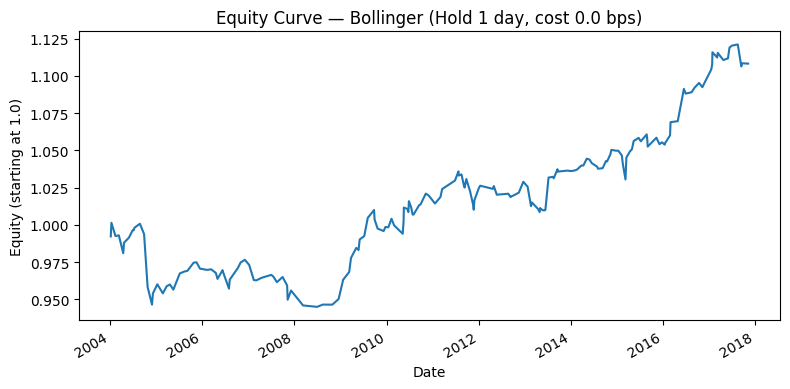

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Read input
# -----------------------------
CSV_PATH = r'D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv'
df = pd.read_csv(CSV_PATH, header=0, index_col=0, parse_dates=True)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# -----------------------------
# 2) Bollinger Bands parameters
# -----------------------------
window = 21
no_of_std = 2

# -----------------------------
# 3) Compute Bollinger Bands & signals
# -----------------------------
rolling_mean = df['Close'].rolling(window).mean()
rolling_std  = df['Close'].rolling(window).std()

df['Rolling Mean']   = rolling_mean
df['Bollinger High'] = rolling_mean + (rolling_std * no_of_std)
df['Bollinger Low']  = rolling_mean - (rolling_std * no_of_std)

# Drop rows with NaNs from the initial window
df = df.dropna(subset=['Rolling Mean','Bollinger High','Bollinger Low']).copy()

# Mean-reversion “cross back inside” rule
buy_cross  = (df['Close'].shift(1) < df['Bollinger Low'].shift(1))  & (df['Close'] >= df['Bollinger Low'])
sell_cross = (df['Close'].shift(1) > df['Bollinger High'].shift(1)) & (df['Close'] <= df['Bollinger High'])

df['bb_dec'] = 0
df.loc[buy_cross,  'bb_dec'] = 1
df.loc[sell_cross, 'bb_dec'] = -1

print("Bollinger strategy signal counts:\n", df['bb_dec'].value_counts())

# -----------------------------
# 4) Accuracy evaluation
# -----------------------------
# Definition:
# For a given horizon H, a signal at time t is "correct" if:
#   - signal == +1 and Close_{t+H} > Close_t
#   - signal == -1 and Close_{t+H} < Close_t
# We compute hit rates for several horizons.

HORIZONS = [1, 5, 10, 20]  # trading days (adjust to taste)
eval_df = df.copy()

# Precompute future returns for each horizon (from t to t+H)
for h in HORIZONS:
    eval_df[f'future_ret_{h}d'] = eval_df['Close'].shift(-h) / eval_df['Close'] - 1.0

# Keep only rows where we have signals and future returns available
signal_mask = eval_df['bb_dec'] != 0

results = []
for h in HORIZONS:
    col = f'future_ret_{h}d'
    valid_mask = signal_mask & eval_df[col].notna()
    sub = eval_df.loc[valid_mask, ['bb_dec', col]].copy()

    # correctness: future move sign matches signal
    sub['correct'] = ((sub['bb_dec'] == 1) & (sub[col] > 0)) | ((sub['bb_dec'] == -1) & (sub[col] < 0))

    # Buy/Sell subsets
    buys  = sub[sub['bb_dec'] == 1]
    sells = sub[sub['bb_dec'] == -1]

    total_signals = len(sub)
    total_correct = int(sub['correct'].sum())
    hit_rate      = sub['correct'].mean() if total_signals > 0 else np.nan

    buy_hit  = buys['correct'].mean() if len(buys)  > 0 else np.nan
    sell_hit = sells['correct'].mean() if len(sells) > 0 else np.nan

    # Avg forward returns (unconditional on correctness)
    avg_ret_all  = sub[col].mean() if total_signals > 0 else np.nan
    avg_ret_buy  = buys[col].mean() if len(buys)  > 0 else np.nan
    avg_ret_sell = sells[col].mean() if len(sells) > 0 else np.nan

    # Counts for a confusion-matrix-like view
    buy_correct  = int(((buys[col]  > 0)).sum())
    buy_wrong    = int(((buys[col]  <= 0)).sum())
    sell_correct = int(((sells[col] < 0)).sum())
    sell_wrong   = int(((sells[col] >= 0)).sum())

    results.append({
        'horizon_days': h,
        'total_signals': total_signals,
        'overall_hit_rate': round(100*hit_rate, 2) if pd.notna(hit_rate) else np.nan,
        'buy_hit_rate': round(100*buy_hit, 2) if pd.notna(buy_hit) else np.nan,
        'sell_hit_rate': round(100*sell_hit, 2) if pd.notna(sell_hit) else np.nan,
        'avg_future_ret_all': avg_ret_all,
        'avg_future_ret_buy': avg_ret_buy,
        'avg_future_ret_sell': avg_ret_sell,
        'buy_correct': buy_correct,
        'buy_wrong': buy_wrong,
        'sell_correct': sell_correct,
        'sell_wrong': sell_wrong,
    })

# Report
res_df = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
print("\n=== Signal Accuracy by Horizon ===")
print(res_df[['horizon_days','total_signals','overall_hit_rate','buy_hit_rate','sell_hit_rate']])

print("\n=== Average Future Returns (Raw) ===")
print(res_df[['horizon_days','avg_future_ret_all','avg_future_ret_buy','avg_future_ret_sell']])

print("\n=== Confusion-style Counts ===")
print(res_df[['horizon_days','buy_correct','buy_wrong','sell_correct','sell_wrong']])

# -----------------------------
# 5) (Optional) Simple 1-day PnL & equity curve
# -----------------------------
# NOTE: This is a toy backtest assuming you hold for 1 day after a signal.
# Entry at today's close is not realistic due to lookahead bias.
# So we enter at next bar's close; exit the bar after that (1-day hold).
# For overlapping signals, this model simply uses the signal at t and ignores position state.

H = 1  # holding period
cost_bp = 0.0  # per round-trip, in basis points (set e.g. = 2.0 for 0.02%)
cost = cost_bp / 10000.0

bt = df.copy()
bt['signal'] = df['bb_dec']
# Entry at next close, exit after H days (next+H)
bt['entry_price'] = bt['Close'].shift(-1)
bt['exit_price']  = bt['Close'].shift(-(1+H))
# Trade return (raw)
bt['trade_ret_raw'] = bt['exit_price'] / bt['entry_price'] - 1.0
# Directional return
bt['trade_ret_dir'] = bt['trade_ret_raw'] * bt['signal']
# Apply simple cost model only when a trade occurs (|signal|==1)
bt['trade_cost'] = np.where(bt['signal'] != 0, cost, 0.0)
bt['trade_ret_net'] = bt['trade_ret_dir'] - bt['trade_cost']

# Keep only rows where we can complete the trade
bt_trades = bt[(bt['signal'] != 0) & bt['trade_ret_net'].notna()].copy()
bt_trades['equity'] = (1.0 + bt_trades['trade_ret_net']).cumprod()

print("\n=== Toy 1-day-hold Backtest Summary ===")
if len(bt_trades) > 0:
    print(f"Trades: {len(bt_trades)}")
    print(f"Hit rate: {(bt_trades['trade_ret_dir'] > 0).mean()*100:.2f}%")
    print(f"Avg trade (net): {bt_trades['trade_ret_net'].mean():.6f}")
    print(f"Cumulative return (net): {bt_trades['equity'].iloc[-1]-1.0:.6f}")
else:
    print("No completed trades for this configuration.")

# Plot the equity curve (if any)
if len(bt_trades) > 0:
    plt.figure(figsize=(8, 4))
    bt_trades['equity'].plot()
    plt.title(f'Equity Curve — Bollinger (Hold {H} day, cost {cost_bp} bps)')
    plt.xlabel('Date')
    plt.ylabel('Equity (starting at 1.0)')
    plt.tight_layout()
    plt.show()

Signal counts:
MA  : sig_ma
-1    1447
 1     452
Name: count, dtype: int64
BB  : sig_bb
-1      53
 0    1790
 1      56
Name: count, dtype: int64

=== Accuracy Comparison (MA vs Bollinger) ===
   horizon_days  total_signals_MA  coverage_pct_MA  overall_hit_rate_%_MA  \
0             1              1899       100.000000              51.660000   
1             5              1899       100.000000              50.500000   
2            10              1899       100.000000              49.240000   
3            20              1899       100.000000              50.870000   

   buy_hit_rate_%_MA  sell_hit_rate_%_MA  total_signals_BB  coverage_pct_BB  \
0          50.220000           52.110000               109         5.740000   
1          50.880000           50.380000               109         5.740000   
2          45.580000           50.380000               109         5.740000   
3          51.330000           50.730000               109         5.740000   

   overall_hit_rate_%_B

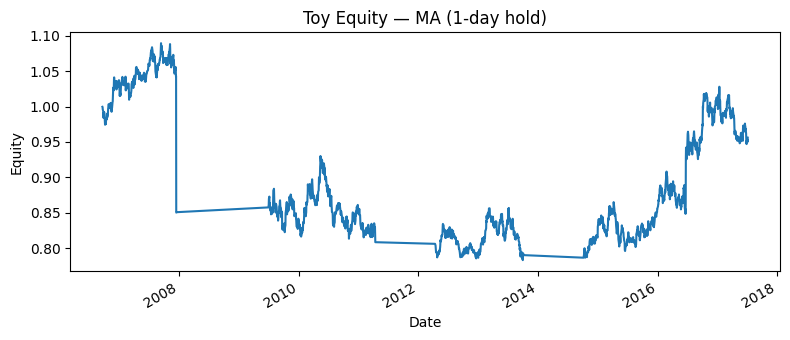

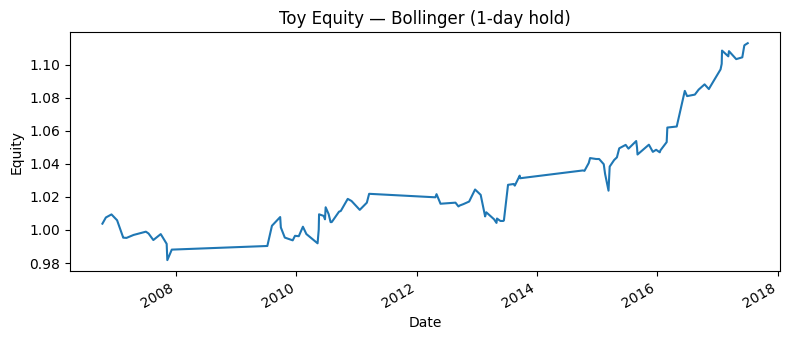

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0) Config
# =========================
CSV_PATH = r'D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv'
HORIZONS = [1, 5, 10, 20]
DEADZONE = 0.0

MA_FAST = 28
MA_SLOW = 260
X_THRESH = 0.05

BB_WINDOW = 21
BB_STD = 2

# =========================
# 1) Load & prep data
# =========================
df = pd.read_csv(CSV_PATH, header=0, index_col=0, parse_dates=True)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.sort_index()

# =========================
# 2) Strategy signals
# =========================
# MA crossover
ma1 = df['Close'].rolling(MA_FAST).mean()
ma2 = df['Close'].rolling(MA_SLOW).mean()
diff = ma1 - ma2
df['sig_ma'] = np.where(diff > X_THRESH, 1, np.where(diff < X_THRESH, -1, 0))

# Bollinger
roll_mean = df['Close'].rolling(BB_WINDOW).mean()
roll_std  = df['Close'].rolling(BB_WINDOW).std()
bb_high = roll_mean + BB_STD * roll_std
bb_low  = roll_mean - BB_STD * roll_std

buy_cross  = (df['Close'].shift(1) < bb_low.shift(1))  & (df['Close'] >= bb_low)
sell_cross = (df['Close'].shift(1) > bb_high.shift(1)) & (df['Close'] <= bb_high)

df['sig_bb'] = 0
df.loc[buy_cross, 'sig_bb']  = 1
df.loc[sell_cross,'sig_bb']  = -1

# ✅ PATCH: assign helper columns correctly
df['ma1'] = ma1
df['ma2'] = ma2
df['diff'] = diff
df['bb_high'] = bb_high
df['bb_low'] = bb_low

# Drop rows that don't yet have indicators
df = df.dropna(subset=['ma1','ma2','bb_high','bb_low']).copy()

print("Signal counts:")
print("MA  :", df['sig_ma'].value_counts(dropna=False).sort_index())
print("BB  :", df['sig_bb'].value_counts(dropna=False).sort_index())

# =========================
# 3) Data labeling (ground truth)
# =========================
for h in HORIZONS:
    fcol = f'future_ret_{h}d'
    lcol = f'label_{h}d'
    df[fcol] = df['Close'].shift(-h) / df['Close'] - 1.0
    if DEADZONE > 0:
        df[lcol] = np.where(df[fcol] > DEADZONE, 1,
                     np.where(df[fcol] < -DEADZONE, -1, 0))
    else:
        df[lcol] = np.where(df[fcol] > 0, 1, -1)

# =========================
# 4) Evaluation helpers
# =========================
def evaluate_strategy(df, sig_col, horizons, deadzone=0.0):
    rows = []
    total_rows = len(df)
    for h in horizons:
        lcol = f'label_{h}d'
        rcol = f'future_ret_{h}d'
        mask = (df[sig_col] != 0) & df[lcol].notna()
        sub = df.loc[mask, [sig_col, lcol, rcol]].copy()
        n = len(sub)

        correct = (sub[sig_col] == sub[lcol])
        hit_rate = correct.mean() if n > 0 else np.nan

        buys  = sub[sub[sig_col] == 1]
        sells = sub[sub[sig_col] == -1]
        buy_hit  = (buys[sig_col] == buys[lcol]).mean() if len(buys)  > 0 else np.nan
        sell_hit = (sells[sig_col] == sells[lcol]).mean() if len(sells) > 0 else np.nan

        buy_correct  = int((buys[lcol] == 1).sum()) if len(buys)  > 0 else 0
        buy_wrong    = int((buys[lcol] != 1).sum()) if len(buys)  > 0 else 0
        sell_correct = int((sells[lcol] == -1).sum()) if len(sells) > 0 else 0
        sell_wrong   = int((sells[lcol] != -1).sum()) if len(sells) > 0 else 0

        avg_ret_all  = sub[rcol].mean() if n > 0 else np.nan
        avg_ret_buy  = buys[rcol].mean() if len(buys)  > 0 else np.nan
        avg_ret_sell = sells[rcol].mean() if len(sells) > 0 else np.nan

        rows.append({
            'horizon_days': h,
            'total_signals': n,
            'coverage_pct': round(100 * n / total_rows, 2) if total_rows > 0 else np.nan,
            'overall_hit_rate_%': round(100 * hit_rate, 2) if pd.notna(hit_rate) else np.nan,
            'buy_hit_rate_%': round(100 * buy_hit, 2) if pd.notna(buy_hit) else np.nan,
            'sell_hit_rate_%': round(100 * sell_hit, 2) if pd.notna(sell_hit) else np.nan,
            'avg_future_ret_all': avg_ret_all,
            'avg_future_ret_buy': avg_ret_buy,
            'avg_future_ret_sell': avg_ret_sell,
            'buy_correct': buy_correct,
            'buy_wrong': buy_wrong,
            'sell_correct': sell_correct,
            'sell_wrong': sell_wrong
        })
    return pd.DataFrame(rows)

# =========================
# 5) Evaluate both strategies
# =========================
res_ma = evaluate_strategy(df, 'sig_ma', HORIZONS, DEADZONE)
res_bb = evaluate_strategy(df, 'sig_bb', HORIZONS, DEADZONE)

key_cols = ['horizon_days','total_signals','coverage_pct','overall_hit_rate_%','buy_hit_rate_%','sell_hit_rate_%']
compare = res_ma[key_cols].merge(res_bb[key_cols], on='horizon_days', suffixes=('_MA', '_BB'))

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print("\n=== Accuracy Comparison (MA vs Bollinger) ===")
print(compare)

print("\n=== Detailed Metrics — MA Strategy ===")
print(res_ma)

print("\n=== Detailed Metrics — Bollinger Strategy ===")
print(res_bb)

# =========================
# 6) (Optional) Tiny toy backtest for each strategy
# =========================
def toy_backtest_1d(df, sig_col, cost_bp=0.0):
    cost = cost_bp / 10000.0
    bt = df.copy()
    bt['signal'] = bt[sig_col]
    bt['entry'] = bt['Close'].shift(-1)
    bt['exit']  = bt['Close'].shift(-2)
    bt['raw']   = bt['exit'] / bt['entry'] - 1.0
    bt['dir']   = bt['raw'] * bt['signal']
    bt['cost']  = np.where(bt['signal'] != 0, cost, 0.0)
    bt['net']   = bt['dir'] - bt['cost']
    trades = bt[(bt['signal'] != 0) & bt['net'].notna()].copy()
    if len(trades) == 0:
        return {'trades': 0, 'hit_rate_%': np.nan, 'avg_trade_net': np.nan, 'cumret_net': np.nan}, trades
    trades['equity'] = (1.0 + trades['net']).cumprod()
    summary = {
        'trades': len(trades),
        'hit_rate_%': round(100 * (trades['dir'] > 0).mean(), 2),
        'avg_trade_net': trades['net'].mean(),
        'cumret_net': trades['equity'].iloc[-1] - 1.0
    }
    return summary, trades

sum_ma, tr_ma = toy_backtest_1d(df, 'sig_ma', cost_bp=0.0)
sum_bb, tr_bb = toy_backtest_1d(df, 'sig_bb', cost_bp=0.0)

print("\n=== Toy Backtest (1-day hold, 0 bps cost) ===")
print("MA :", sum_ma)
print("BB :", sum_bb)

if len(tr_ma) > 0:
    plt.figure(figsize=(8, 3.5))
    tr_ma['equity'].plot()
    plt.title('Toy Equity — MA (1-day hold)')
    plt.xlabel('Date'); plt.ylabel('Equity')
    plt.tight_layout(); plt.show()

if len(tr_bb) > 0:
    plt.figure(figsize=(8, 3.5))
    tr_bb['equity'].plot()
    plt.title('Toy Equity — Bollinger (1-day hold)')
    plt.xlabel('Date'); plt.ylabel('Equity')
    plt.tight_layout(); plt.show()


=== Accuracy Comparison (MA vs Bollinger) ===
   horizon_days  total_signals_MA  coverage_%_MA  overall_hit_rate_%_MA  \
0             1              1899     100.000000              51.660000   
1             5              1899     100.000000              50.500000   
2            10              1899     100.000000              49.240000   
3            20              1899     100.000000              50.870000   

   buy_hit_rate_%_MA  sell_hit_rate_%_MA  total_signals_BB  coverage_%_BB  \
0          50.220000           52.110000               109       5.740000   
1          50.880000           50.380000               109       5.740000   
2          45.580000           50.380000               109       5.740000   
3          51.330000           50.730000               109       5.740000   

   overall_hit_rate_%_BB  buy_hit_rate_%_BB  sell_hit_rate_%_BB  
0              52.290000          41.070000           64.150000  
1              56.880000          55.360000           58.49

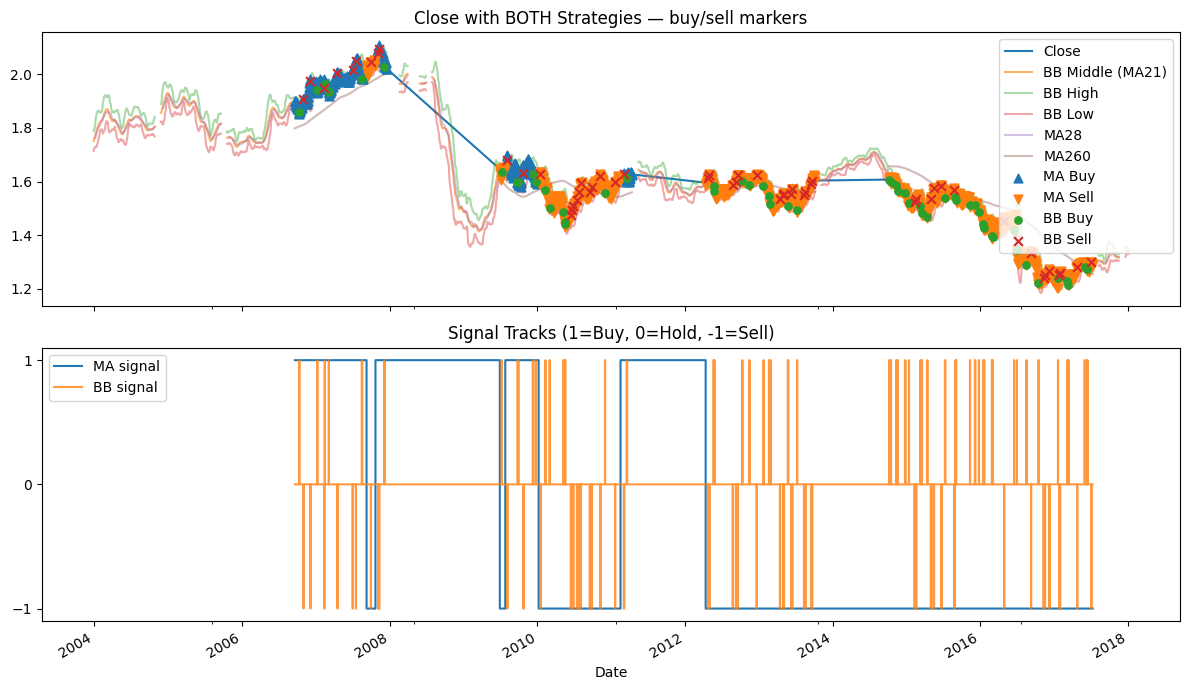

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0) Config
# =========================
CSV_PATH   = r'D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv'
HORIZONS   = [1, 5, 10, 20]  # evaluate multiple horizons
H_PRIMARY  = 5               # <- main horizon to judge "which is better"
DEADZONE   = 0.0             # set >0 to ignore tiny moves (labels can be 0)

# MA-crossover params (your earlier settings)
MA_FAST   = 28
MA_SLOW   = 260
X_THRESH  = 0.05             # threshold on (MA1 - MA2)

# Bollinger params
BB_WINDOW = 21
BB_STD    = 2

# =========================
# 1) Load & prep data
# =========================
df = pd.read_csv(CSV_PATH, header=0, index_col=0, parse_dates=True)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.sort_index()

# =========================
# 2) Build indicators & signals
# =========================
# --- MA crossover ---
ma1  = df['Close'].rolling(MA_FAST).mean()
ma2  = df['Close'].rolling(MA_SLOW).mean()
diff = ma1 - ma2
df['sig_ma'] = np.where(diff > X_THRESH, 1, np.where(diff < X_THRESH, -1, 0))

# --- Bollinger (cross back inside bands) ---
roll_mean = df['Close'].rolling(BB_WINDOW).mean()
roll_std  = df['Close'].rolling(BB_WINDOW).std()
bb_high   = roll_mean + BB_STD * roll_std
bb_low    = roll_mean - BB_STD * roll_std

buy_cross  = (df['Close'].shift(1) < bb_low.shift(1))  & (df['Close'] >= bb_low)
sell_cross = (df['Close'].shift(1) > bb_high.shift(1)) & (df['Close'] <= bb_high)

df['sig_bb'] = 0
df.loc[buy_cross,  'sig_bb'] = 1
df.loc[sell_cross, 'sig_bb'] = -1

# keep helper columns
df['ma1'] = ma1; df['ma2'] = ma2; df['diff'] = diff
df['bb_high'] = bb_high; df['bb_low'] = bb_low

# Drop rows that don't yet have indicators
df = df.dropna(subset=['ma1','ma2','bb_high','bb_low']).copy()

# =========================
# 3) Data labeling (ground truth)
# =========================
for h in HORIZONS:
    fcol = f'future_ret_{h}d'
    lcol = f'label_{h}d'
    df[fcol] = df['Close'].shift(-h) / df['Close'] - 1.0
    if DEADZONE > 0:
        df[lcol] = np.where(df[fcol] >  DEADZONE,  1,
                     np.where(df[fcol] < -DEADZONE, -1, 0))
    else:
        # binary labels (+1 / -1)
        df[lcol] = np.where(df[fcol] > 0, 1, -1)

# =========================
# 4) Evaluation
# =========================
def evaluate_strategy(df, sig_col, horizons):
    rows = []
    total_rows = len(df)
    for h in horizons:
        lcol = f'label_{h}d'
        rcol = f'future_ret_{h}d'
        mask = (df[sig_col] != 0) & df[lcol].notna()
        sub = df.loc[mask, [sig_col, lcol, rcol]].copy()
        n = len(sub)

        # accuracy (hit rate): signal == label
        hit_rate = (sub[sig_col] == sub[lcol]).mean() if n > 0 else np.nan

        # buy/sell split
        buys  = sub[sub[sig_col] == 1]
        sells = sub[sub[sig_col] == -1]
        buy_hit  = (buys[sig_col] == buys[lcol]).mean() if len(buys)  > 0 else np.nan
        sell_hit = (sells[sig_col] == sells[lcol]).mean() if len(sells) > 0 else np.nan

        # average future returns (on signaled bars only)
        avg_ret_all  = sub[rcol].mean() if n > 0 else np.nan
        avg_ret_buy  = buys[rcol].mean() if len(buys)  > 0 else np.nan
        avg_ret_sell = sells[rcol].mean() if len(sells) > 0 else np.nan

        rows.append({
            'horizon_days': h,
            'total_signals': n,
            'coverage_%': round(100 * n / total_rows, 2) if total_rows > 0 else np.nan,
            'overall_hit_rate_%': round(100 * hit_rate, 2) if pd.notna(hit_rate) else np.nan,
            'buy_hit_rate_%': round(100 * buy_hit, 2) if pd.notna(buy_hit) else np.nan,
            'sell_hit_rate_%': round(100 * sell_hit, 2) if pd.notna(sell_hit) else np.nan,
            'avg_future_ret_all': avg_ret_all,
            'avg_future_ret_buy': avg_ret_buy,
            'avg_future_ret_sell': avg_ret_sell
        })
    return pd.DataFrame(rows)

res_ma = evaluate_strategy(df, 'sig_ma', HORIZONS)
res_bb = evaluate_strategy(df, 'sig_bb', HORIZONS)

# side-by-side key comparison
key_cols = ['horizon_days','total_signals','coverage_%','overall_hit_rate_%','buy_hit_rate_%','sell_hit_rate_%']
compare = res_ma[key_cols].merge(res_bb[key_cols], on='horizon_days', suffixes=('_MA', '_BB'))

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print("\n=== Accuracy Comparison (MA vs Bollinger) ===")
print(compare)

print("\n=== Detailed Metrics — MA Strategy ===");  print(res_ma)
print("\n=== Detailed Metrics — Bollinger Strategy ===");  print(res_bb)

# =========================
# 5) Decide which is "working good" and why (uses H_PRIMARY)
# =========================
def pick_winner(res_ma, res_bb, h_primary):
    row_ma = res_ma[res_ma['horizon_days'] == h_primary].iloc[0]
    row_bb = res_bb[res_bb['horizon_days'] == h_primary].iloc[0]

    # primary criterion: overall hit rate
    ma_hit = row_ma['overall_hit_rate_%']; bb_hit = row_bb['overall_hit_rate_%']
    # secondary: avg future return on signaled bars
    ma_ret = row_ma['avg_future_ret_all']; bb_ret = row_bb['avg_future_ret_all']
    # tertiary: coverage
    ma_cov = row_ma['coverage_%']; bb_cov = row_bb['coverage_%']

    if pd.isna(ma_hit) and pd.isna(bb_hit):
        verdict = "Neither strategy has enough signals to evaluate."
        details = ""
        return verdict, details

    if (not pd.isna(ma_hit)) and (not pd.isna(bb_hit)):
        if ma_hit > bb_hit + 0.01:  # 1 percentage point buffer
            winner = "MA Crossover"
            why = [f"higher hit rate at {h_primary}d ({ma_hit:.2f}% vs {bb_hit:.2f}%)"]
            if not pd.isna(ma_ret) and not pd.isna(bb_ret):
                if ma_ret > bb_ret: why.append(f"higher avg forward return ({ma_ret:.6f} vs {bb_ret:.6f})")
            why.append(f"coverage {ma_cov:.2f}% vs {bb_cov:.2f}%")
        elif bb_hit > ma_hit + 0.01:
            winner = "Bollinger"
            why = [f"higher hit rate at {h_primary}d ({bb_hit:.2f}% vs {ma_hit:.2f}%)"]
            if not pd.isna(ma_ret) and not pd.isna(bb_ret):
                if bb_ret > ma_ret: why.append(f"higher avg forward return ({bb_ret:.6f} vs {ma_ret:.6f})")
            why.append(f"coverage {bb_cov:.2f}% vs {ma_cov:.2f}%")
        else:
            # tie: decide by avg return, then coverage
            if not pd.isna(ma_ret) and not pd.isna(bb_ret):
                if ma_ret > bb_ret + 1e-12:
                    winner = "MA Crossover"
                    why = [f"similar hit rate, better avg forward return ({ma_ret:.6f} vs {bb_ret:.6f})",
                           f"coverage {ma_cov:.2f}% vs {bb_cov:.2f}%"]
                elif bb_ret > ma_ret + 1e-12:
                    winner = "Bollinger"
                    why = [f"similar hit rate, better avg forward return ({bb_ret:.6f} vs {ma_ret:.6f})",
                           f"coverage {bb_cov:.2f}% vs {ma_cov:.2f}%"]
                else:
                    # final tiebreaker coverage
                    if ma_cov >= bb_cov:
                        winner = "MA Crossover"
                        why = ["nearly identical metrics; higher coverage means more opportunities"]
                    else:
                        winner = "Bollinger"
                        why = ["nearly identical metrics; higher coverage means more opportunities"]
            else:
                winner = "MA Crossover" if ma_cov >= bb_cov else "Bollinger"
                why = ["hit rates nearly equal; picked the one with higher coverage"]
        verdict = f"{winner} works better for a {h_primary}-day label."
        details = "Reasons: " + "; ".join(why) + "."
        return verdict, details

    # If only one has a hit rate
    if not pd.isna(ma_hit):
        return (f"MA Crossover works better for a {h_primary}-day label.",
                f"Reasons: Bollinger had insufficient data; MA hit rate {ma_hit:.2f}%, coverage {ma_cov:.2f}%.")

    return (f"Bollinger works better for a {h_primary}-day label.",
            f"Reasons: MA had insufficient data; Bollinger hit rate {bb_hit:.2f}%, coverage {bb_cov:.2f}%.")

verdict, explanation = pick_winner(res_ma, res_bb, H_PRIMARY)
print("\n=== Verdict ===")
print(verdict)
print(explanation)

# =========================
# 6) One figure showing BOTH signals
# =========================
plt.figure(figsize=(12, 7))

# --- Top: price with both strategies' buy/sell markers ---
ax1 = plt.subplot(2, 1, 1)
df['Close'].plot(ax=ax1, label='Close')
# show MA and Bollinger context lightly (optional)
roll_mean.plot(ax=ax1, alpha=0.6, label='BB Middle (MA21)')
bb_high.plot(ax=ax1, alpha=0.4, label='BB High'); bb_low.plot(ax=ax1, alpha=0.4, label='BB Low')
ma1.plot(ax=ax1, alpha=0.4, label=f'MA{MA_FAST}'); ma2.plot(ax=ax1, alpha=0.4, label=f'MA{MA_SLOW}')

# Markers for MA signals
ma_buys  = df[df['sig_ma'] == 1]
ma_sells = df[df['sig_ma'] == -1]
ax1.scatter(ma_buys.index,  ma_buys['Close'],  marker='^', s=40, label='MA Buy',  zorder=3)
ax1.scatter(ma_sells.index, ma_sells['Close'], marker='v', s=40, label='MA Sell', zorder=3)

# Markers for Bollinger signals
bb_buys  = df[df['sig_bb'] == 1]
bb_sells = df[df['sig_bb'] == -1]
ax1.scatter(bb_buys.index,  bb_buys['Close'],  marker='o', s=28, label='BB Buy',  zorder=3)
ax1.scatter(bb_sells.index, bb_sells['Close'], marker='x', s=40, label='BB Sell', zorder=3)

ax1.set_title('Close with BOTH Strategies — buy/sell markers')
ax1.set_xlabel(''); ax1.legend(loc='best')

# --- Bottom: overlay of both signal tracks ---
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
df['sig_ma'].plot(ax=ax2, drawstyle='steps-post', label='MA signal')
df['sig_bb'].plot(ax=ax2, drawstyle='steps-post', alpha=0.8, label='BB signal')
ax2.set_yticks([-1, 0, 1]); ax2.set_title('Signal Tracks (1=Buy, 0=Hold, -1=Sell)')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()